In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [70]:
# 2. Load Dataset

df = pd.read_csv('star_classification.csv')
print("Shape:", df.shape)
df.head()

Shape: (100000, 18)


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [71]:
# 3. Basic Info

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64


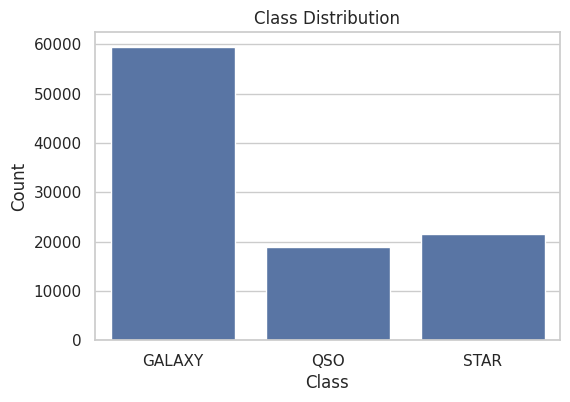

In [72]:
# 4. Class Distribution

print(df['class'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='class', data=df)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [73]:
# 5. Missing Values

print(df.isnull().sum())

obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64


In [74]:
# 6. Duplicate Rows & Invalid Values

print("Duplicates:", df.duplicated().sum())

for col in df.select_dtypes(include=np.number).columns:
    count = (df[col] == -9999).sum()
    if count > 0:
        print(f"{col}: {count} rows")

Duplicates: 0
u: 1 rows
g: 1 rows
z: 1 rows


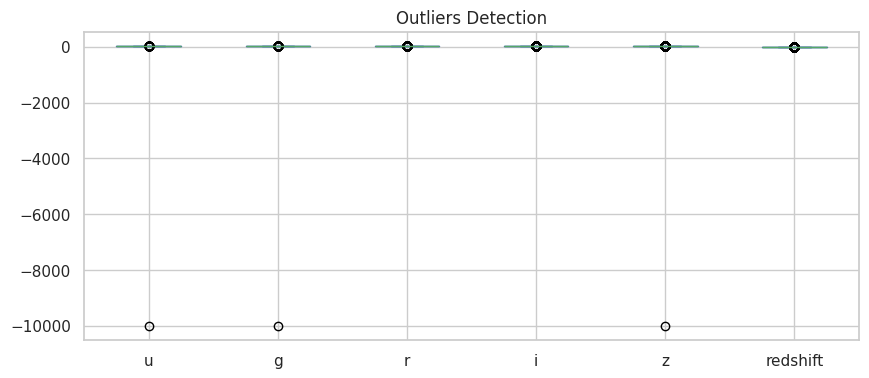

In [75]:
# 7. Outliers - Boxplot

photometric_features = ['u', 'g', 'r', 'i', 'z', 'redshift']

df[photometric_features].plot(kind='box', figsize=(10,4))
plt.title("Outliers Detection")
plt.show()

In [76]:
# 8. Outliers IQR
for col in photometric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers")

u: 56 outliers
g: 99 outliers
r: 132 outliers
i: 198 outliers
z: 320 outliers
redshift: 8990 outliers


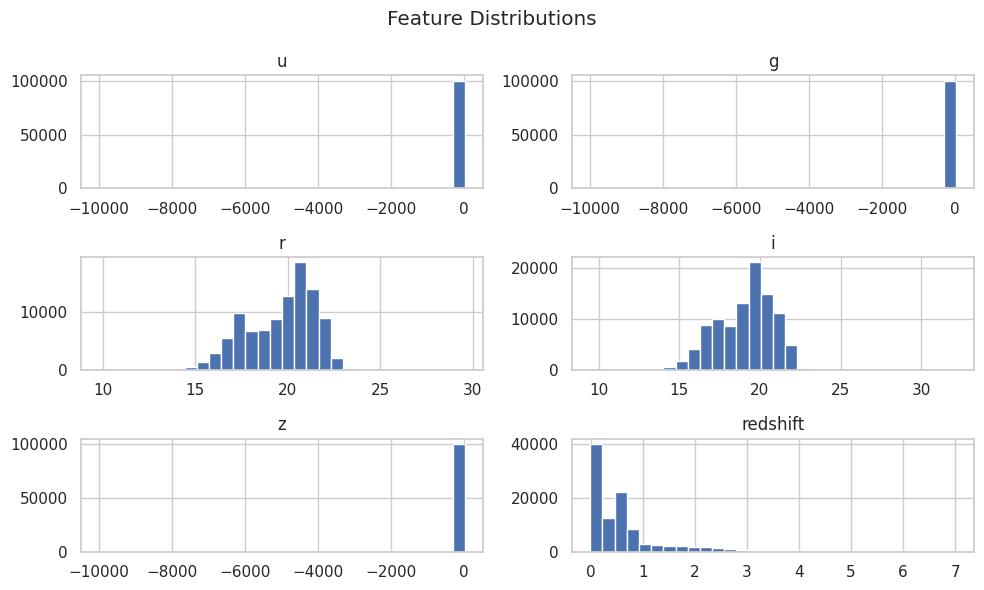

In [77]:
 # 9. Histograms

df[photometric_features].hist(figsize=(10,6), bins=30)
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

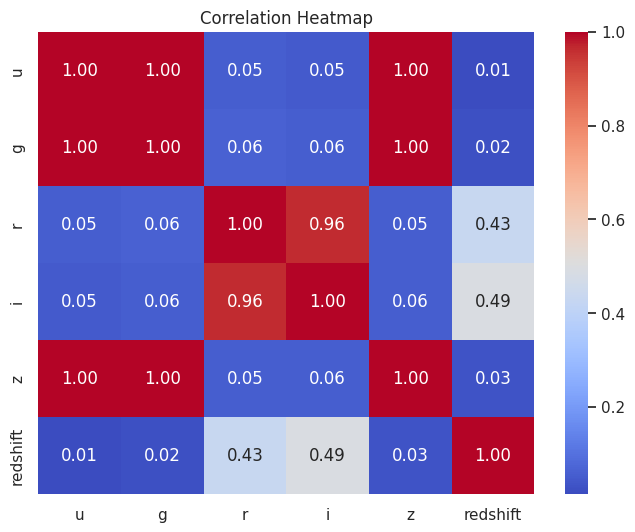

In [78]:
# 10. Correlation Heatmap

plt.figure(figsize=(8,6))
sns.heatmap(df[photometric_features].corr(), annot=True,
            fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

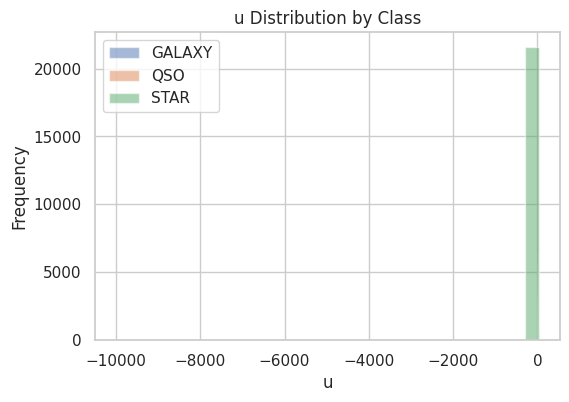

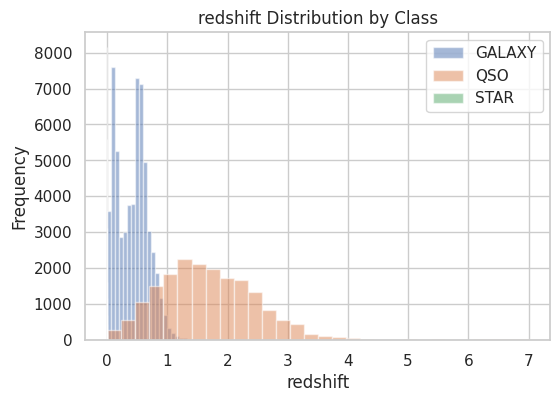

In [ ]:
 # 11. Distribution by Class
for col in ['u', 'redshift']:
    plt.figure(figsize=(6,4))
    
    for cls in df['class'].unique():
        subset = df[df['class'] == cls]
        plt.hist(subset[col], bins=30, alpha=0.5, label=cls)
    plt.title(f"{col} Distribution by Class")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

In [80]:
# Remove duplicate rows from dataset

df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [81]:
# Replace invalid values (-9999) with NaN then handle them

df.replace(-9999, np.nan, inplace=True)


In [ ]:
# Handle missing values in dataset
# We replace missing values with median (numerical) and mode (categorical)

for col in df.select_dtypes(include=np.number):
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include='object')             :
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_42102/1635292708.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_42102/1635292708.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [83]:
# Detect and remove outliers using Local Outlier Factor (LOF)

from sklearn.neighbors import LocalOutlierFactor

photometric_features = ['u', 'g', 'r', 'i', 'z', 'redshift']

# Select features for outlier detection
X = df[photometric_features]

lof = LocalOutlierFactor(contamination=0.05)
y_pred = lof.fit_predict(X)

df = df[y_pred == 1]

In [84]:
# Convert categorical labels into numerical values

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

In [85]:
# Split dataset into training and testing sets

from sklearn.model_selection import train_test_split

X = df.drop('class', axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 66500
Test size: 28500


In [86]:
# Balance classes using SMOTE

from imblearn.over_sampling import SMOTE
from collections import Counter

sm = SMOTE(random_state=42)

print("Before SMOTE:", Counter(y_train))

X_train, y_train = sm.fit_resample(X_train, y_train)

print("After SMOTE:", Counter(y_train))

Before SMOTE: Counter({0: 39838, 2: 14056, 1: 12606})
After SMOTE: Counter({0: 39838, 2: 39838, 1: 39838})


In [87]:
# Standardize features to improve model performance

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [88]:
df_original = df.copy()

# Modeling Before Feature Engineering

In [89]:
from sklearn.model_selection import train_test_split

X_before = df_original.drop("class", axis=1)
y_before = df_original["class"]

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_before, y_before, test_size=0.2, random_state=42, stratify=y_before
)

## Logistic Regression (Before)

In [90]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_before = LogisticRegression(max_iter=1000)
log_before.fit(X_train_b, y_train_b)

y_pred_log_b = log_before.predict(X_test_b)
acc_log_before = accuracy_score(y_test_b, y_pred_log_b)

print("Logistic Before:", acc_log_before)

Logistic Before: 0.6026315789473684


## Random Forest (Before)

In [91]:
from sklearn.ensemble import RandomForestClassifier

rf_before = RandomForestClassifier(n_estimators=200, random_state=42)
rf_before.fit(X_train_b, y_train_b)

y_pred_rf_b = rf_before.predict(X_test_b)
acc_rf_before = accuracy_score(y_test_b, y_pred_rf_b)

print("Random Forest Before:", acc_rf_before)

Random Forest Before: 0.9795263157894737


# KNN (Before)

In [92]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn_before = KNeighborsClassifier(n_neighbors=5)

knn_before.fit(X_train_b, y_train_b)

y_pred_knn_b = knn_before.predict(X_test_b)

acc_knn_before = accuracy_score(y_test_b, y_pred_knn_b)

print("KNN Before Feature Selection:", acc_knn_before)

KNN Before Feature Selection: 0.715421052631579


## **Feature Engineering**

In [93]:
### 1. Correlation Analysis

In [94]:
corr_matrix = df.corr(numeric_only=True)

target_corr = corr_matrix['class'].sort_values(ascending=False)

print(target_corr)

class          1.000000
z              0.078489
cam_col        0.022875
i              0.022398
delta          0.014619
MJD            0.001594
plate         -0.007669
spec_obj_ID   -0.007670
alpha         -0.017227
field_ID      -0.031884
obj_ID        -0.037573
run_ID        -0.037575
fiber_ID      -0.041816
redshift      -0.046958
r             -0.074277
g             -0.234556
u             -0.283304
rerun_ID            NaN
Name: class, dtype: float64


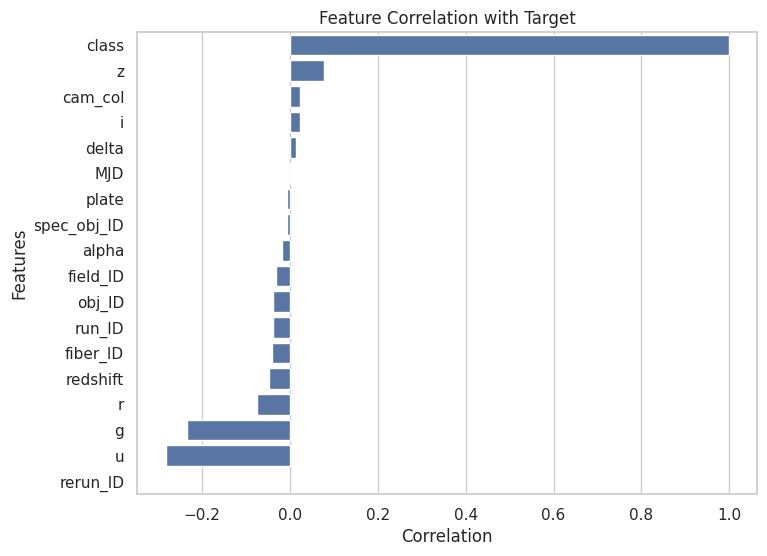

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.barplot(x=target_corr.values, y=target_corr.index)

plt.title("Feature Correlation with Target")
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.show()

 Feature Importance using Random Forest

In [96]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

X = df.drop("class", axis=1)
y = df["class"]

model = RandomForestClassifier(random_state=42)
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance)

redshift       0.596282
z              0.085555
g              0.060969
u              0.055650
i              0.054393
spec_obj_ID    0.034985
r              0.033502
plate          0.023335
MJD            0.018773
delta          0.007818
alpha          0.007067
run_ID         0.005447
fiber_ID       0.005220
field_ID       0.004955
obj_ID         0.004015
cam_col        0.002034
rerun_ID       0.000000
dtype: float64


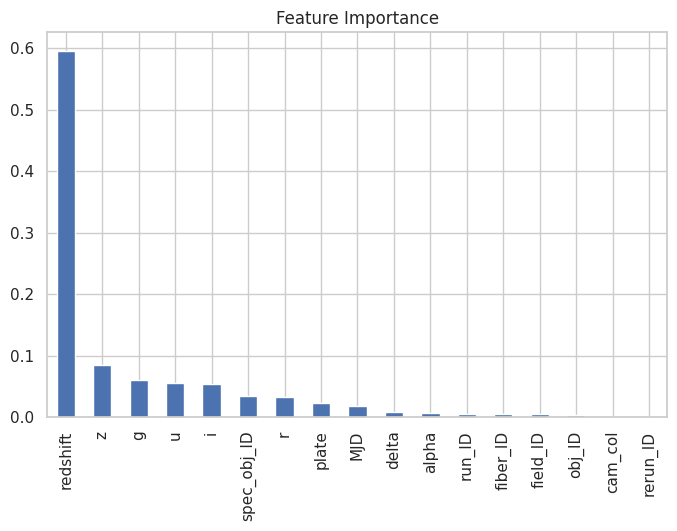

In [97]:
importance.plot(kind='bar', figsize=(8,5))
plt.title("Feature Importance")
plt.show()

 Selected Features

In [98]:
selected_features = importance[importance > 0.05].index

print("Selected Features:", selected_features)

df = df[selected_features.tolist() + ['class']]

df.head()

Selected Features: Index(['redshift', 'z', 'g', 'u', 'i'], dtype='object')


,redshift,z,g,u,i,class
0,0.634794,18.79371,22.27530,23.87882,19.16573,0
1,0.779136,21.61427,22.83188,24.77759,21.16812,0
2,0.644195,18.94827,22.66389,25.26307,19.34857,0
3,0.932346,19.25010,23.77656,22.13682,20.50454,0
4,0.116123,15.54461,17.58028,19.43718,15.97711,0


### Feature Engineering Summary

- تم استخدام Correlation Analysis لتحديد العلاقة بين كل Feature و الـ target.
- تم استخدام Random Forest لاستخراج Feature Importance.
- تم اختيار الفيتشرز الأكثر تأثيرًا بناءً على الطريقتين.
- تم حذف الفيتشرز ضعيفة التأثير لتقليل الـ Noise وتحسين الأداء.
- لم يتم استخدام PCA لأن عدد الفيتشرز قليل (Low Dimensional Data).

# Modeling After Feature Engineering


In [99]:
X_after = df.drop("class", axis=1)
y_after = df["class"]

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_after, y_after, test_size=0.2, random_state=42, stratify=y_after
)

## Logistic Regression (After)

In [100]:
log_after = LogisticRegression(max_iter=1000)
log_after.fit(X_train_a, y_train_a)

y_pred_log_a = log_after.predict(X_test_a)
acc_log_after = accuracy_score(y_test_a, y_pred_log_a)

print("Logistic After:", acc_log_after)

Logistic After: 0.9600526315789474


## Random Forest (After)

In [101]:
rf_after = RandomForestClassifier(n_estimators=200, random_state=42)
rf_after.fit(X_train_a, y_train_a)

y_pred_rf_a = rf_after.predict(X_test_a)
acc_rf_after = accuracy_score(y_test_a, y_pred_rf_a)

print("Random Forest After:", acc_rf_after)

Random Forest After: 0.9793684210526316


KNN (After)

In [102]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn_after = KNeighborsClassifier(n_neighbors=5)

knn_after.fit(X_train_a, y_train_a)

y_pred_knn_a = knn_after.predict(X_test_a)

acc_knn_after = accuracy_score(y_test_a, y_pred_knn_a)

print("KNN After Feature Selection:", acc_knn_after)

KNN After Feature Selection: 0.957421052631579


### Comparison

In [106]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression", "Logistic Regression",
        "Random Forest", "Random Forest",
        "KNN", "KNN"
    ],
    "State": [
        "Before", "After",
        "Before", "After",
        "Before", "After"
    ],
    "Accuracy": [
        acc_log_before, acc_log_after,
        acc_rf_before, acc_rf_after,
        acc_knn_before, acc_knn_after
    ]
})

comparison

,Model,State,Accuracy
0,Logistic Regression,Before,0.602632
1,Logistic Regression,After,0.960053
2,Random Forest,Before,0.979526
3,Random Forest,After,0.979368
4,KNN,Before,0.715421
5,KNN,After,0.957421


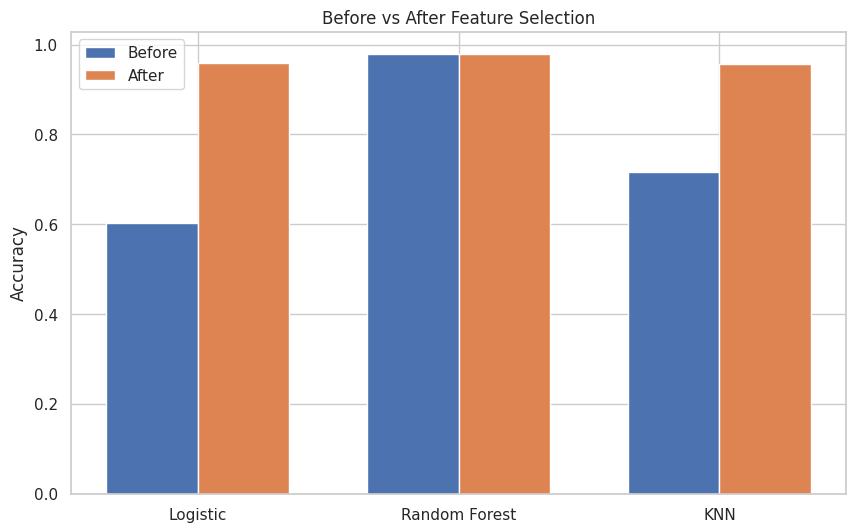

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

models = ['Logistic', 'Random Forest', 'KNN']

before = [acc_log_before, acc_rf_before, acc_knn_before]
after = [acc_log_after, acc_rf_after, acc_knn_after]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(x - width /2, before, width, label='Before')
plt.bar(x + width/2, after, width, label='After')

plt.xticks(x, models)
plt.title("Before vs After Feature Selection")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

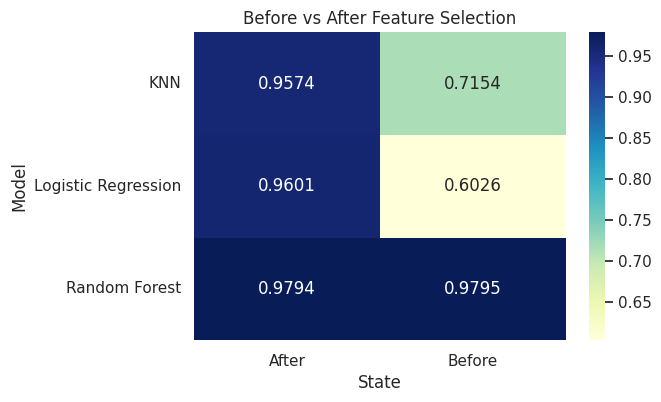

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = comparison.pivot(index="Model", columns="State", values="Accuracy")

plt.figure(figsize=(6,4))
sns.heatmap(pivot, annot=True, cmap="YlGnBu", fmt=".4f")

plt.title("Before vs After Feature Selection")
plt.show()